<a href="https://colab.research.google.com/github/varsha2410ab/PEP---SUMMER/blob/main/NLP_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! !pip install nltk worldcloud

/bin/bash: line 1: !pip: command not found


In [2]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter
import nltk
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
nltk.download('stopwords') ##Downloading stopword corpus

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import os
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch
from collections import defaultdict
from collections import Counter
# import keras
# from keras.models import Sequential
# from keras.initializers import Constant
# from keras.layers import (LSTM,
#                           Embedding,
#                           BatchNormalization,
#                           Dense,
#                           TimeDistributed,
#                           Dropout,
#                           Bidirectional,
#                           Flatten,
#                           GlobalMaxPool1D)
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
# from keras.layers.embeddings import Embedding
# from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
# from keras.optimizers import Adam

# from sklearn.metrics import (
#     precision_score,
#     recall_score,
#     f1_score,
#     classification_report,
#     accuracy_score
# )

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df = pd.read_csv('spam.csv', encoding = "latin-1")

df = df.dropna(how="any", axis = 1)
df.columns = ['target', 'message']
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['message_len'] = df['message'].apply(lambda x: len(x.split(' ')))
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [ ]:
max(df['message_len'])


171

In [ ]:
min(df['message_len'])

1

In [ ]:
balance_counts = df.groupby('target')['target'].agg('count').values
print(balance_counts)

[4825  747]


In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text=[balance_counts[0]],
    textposition='auto',
    marker_color='indianred'
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition='auto',
    marker_color='lightsalmon'

))

fig.update_layout(barmode='stack', xaxis={'categoryorder':'total descending'})
fig.show()
#

In [ ]:
ham_df = df[df['target'] == 'ham']['message_len'].value_counts().sort_index()
spam_df = df[df['target'] == 'spam']['message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ham_df.index,
    y=ham_df.values,
    name='ham',
    fill='tozeroy',
    mode='lines+markers'
))

fig.add_trace(go.Scatter(
    x=spam_df.index,
    y=spam_df.values,
    name='spam',
    fill='tozeroy',
    mode='lines+markers'
))

fig.update_layout(
    xaxis_title='Message Length',
    yaxis_title='Count'
)

fig.update_xaxes(range=[0,70])

fig.show()


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

df['message_clean'] = df['message'].apply(clean_text)
df.head()

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

<>:3: SyntaxWarning:

invalid escape sequence '\['

<>:4: SyntaxWarning:

invalid escape sequence '\S'

<>:8: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipykernel_1000/3263597791.py:3: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_1000/3263597791.py:4: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_1000/3263597791.py:8: SyntaxWarning:

invalid escape sequence '\w'



,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah i dont think he goes to usf he lives aroun...


In [ ]:
stop_words= stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goes usf lives around though


In [ ]:
stemmer = nltk.SnowballStemmer("english")
def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

df['message_clean'] = df['message_clean'].apply(stem_words)

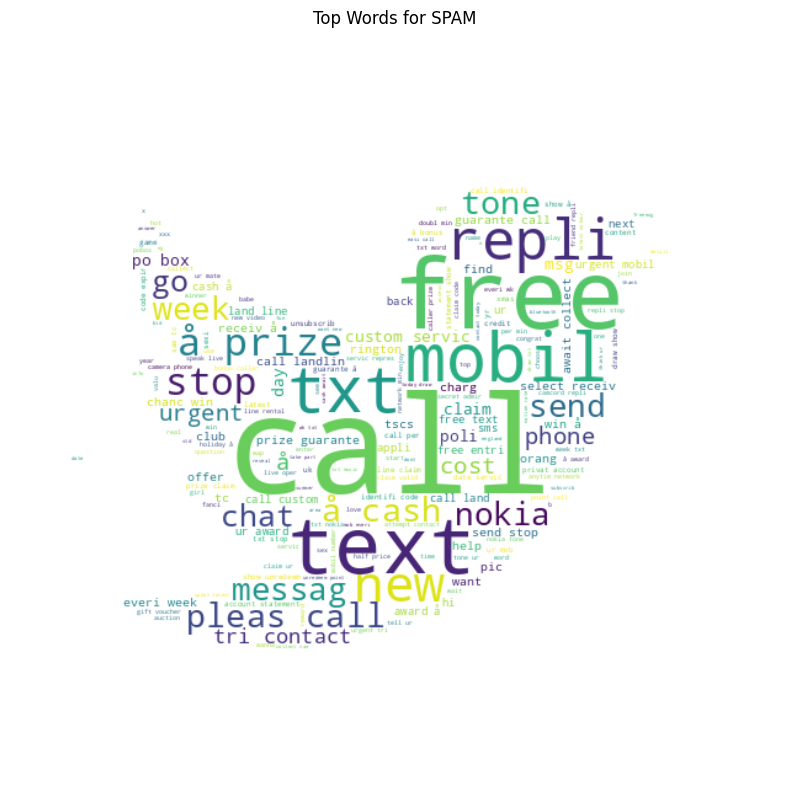

In [ ]:
twitter_mask = np.array(Image.open("twitter_mask4.jpeg"))

wc = WordCloud(
    background_color="white",
    max_words=200,
    mask=twitter_mask
)

wc.generate(' '.join(text for text in df.loc[df['target'] == 'spam', 'message_clean']))
plt.figure(figsize=(18,10))
plt.title('Top Words for SPAM')
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [6]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [8]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df.dropna(how='any', axis=1)
df.columns = ['target', 'message']

df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5572, 2)

In [10]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()

x_train_dtm = vect.fit_transform(x_train)
x_test_dtm = vect.transform(x_test)

In [12]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
x_test_tfidf = tfidf_transformer.transform(x_test_dtm)